In [1]:
import numpy as np
import pandas as pd

# Configuração
np.random.seed(42)
n_samples = 100

# 1. Geração das Variáveis (Simulação de Sensores)
# Temperatura (ºC): 100 a 400
temperatura = np.random.uniform(100, 400, n_samples)
# Pressão (atm): 10 a 80
pressao = np.random.uniform(10, 80, n_samples)
# Vibração (mm/s): 0 a 10 (níveis de vibração na estrutura)
vibracao = np.random.uniform(0, 10, n_samples)

# 2. Definição da Fronteira de Segurança (Física do Problema)
# Equação do plano: w1*T + w2*P + w3*V + bias = 0
# A vibração tem um peso alto no risco (ex: 4.0), a pressão médio (1.0) e temp (0.1)
w_T = 0.1
w_P = 1.0
w_V = 4.0
bias = -100 # Limiar de segurança

data = []
margin = 5 # Margem para garantir separabilidade linear clara

for i in range(n_samples):
    # Cálculo do Potencial de Risco
    potencial = (w_T * temperatura[i]) + (w_P * pressao[i]) + (w_V * vibracao[i]) + bias

    # Ignora pontos muito próximos da fronteira (ruído ambíguo)
    if abs(potencial) < margin:
        continue

    # Classificação: +1 (Crítico/Explosão), -1 (Seguro)
    classe = 1 if potencial > 0 else -1

    data.append([
        round(temperatura[i], 2),
        round(pressao[i], 2),
        round(vibracao[i], 2),
        classe
    ])

# Criação do DataFrame
df_reator = pd.DataFrame(data, columns=['Temperatura', 'Pressao', 'Vibracao', 'Status'])

# Salvar
df_reator.to_csv('reator_3vars.csv', index=False)
print(f"Dados gerados com {len(df_reator)} amostras.")
print(df_reator['Status'].value_counts())

Dados gerados com 87 amostras.
Status
-1    57
 1    30
Name: count, dtype: int64


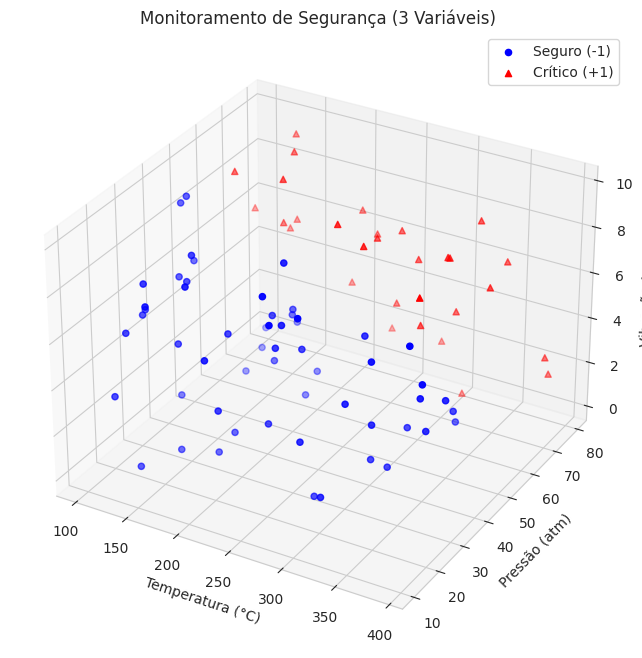

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Separar classes
seguro = df_reator[df_reator['Status'] == -1]
critico = df_reator[df_reator['Status'] == 1]

# Plotar pontos
ax.scatter(seguro['Temperatura'], seguro['Pressao'], seguro['Vibracao'],
           c='blue', marker='o', label='Seguro (-1)')
ax.scatter(critico['Temperatura'], critico['Pressao'], critico['Vibracao'],
           c='red', marker='^', label='Crítico (+1)')

ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Pressão (atm)')
ax.set_zlabel('Vibração (mm/s)')
ax.set_title('Monitoramento de Segurança (3 Variáveis)')
plt.legend()
plt.show()